Libraries ready ✅
Data loaded successfully!
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         30 non-null     datetime64[ns]
 1   AQI          30 non-null     int64         
 2   Humidity     30 non-null     int64         
 3   Temperature  30 non-null     int64         
 4   TomatoPrice  30 non-null     int64         
 5   OnionPrice   30 non-null     int64         
 6   Fatigue      30 non-null     int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 1.8 KB
None

Descriptive Stats:
                      Date         AQI   Humidity  Temperature  TomatoPrice  \
count                   30   30.000000  30.000000    30.000000    30.000000   
mean   2026-01-15 12:00:00  129.566667  72.933333    29.133333    37.266667   
min    2026-01-01 00:00:00   98.000000  65.000000    26.000000    30.000000   
25% 

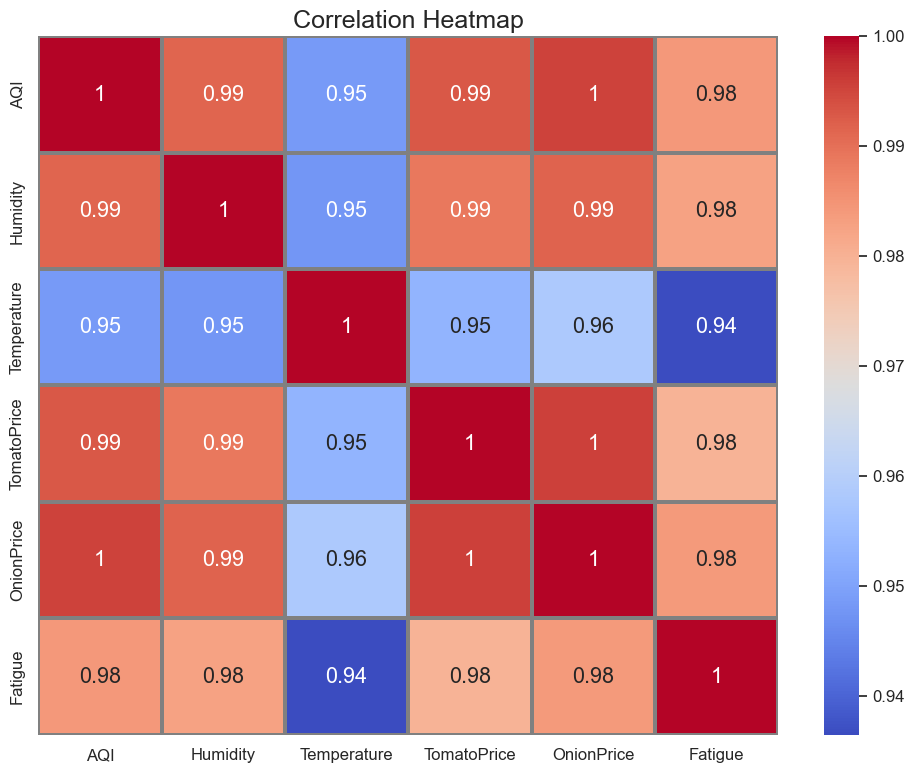

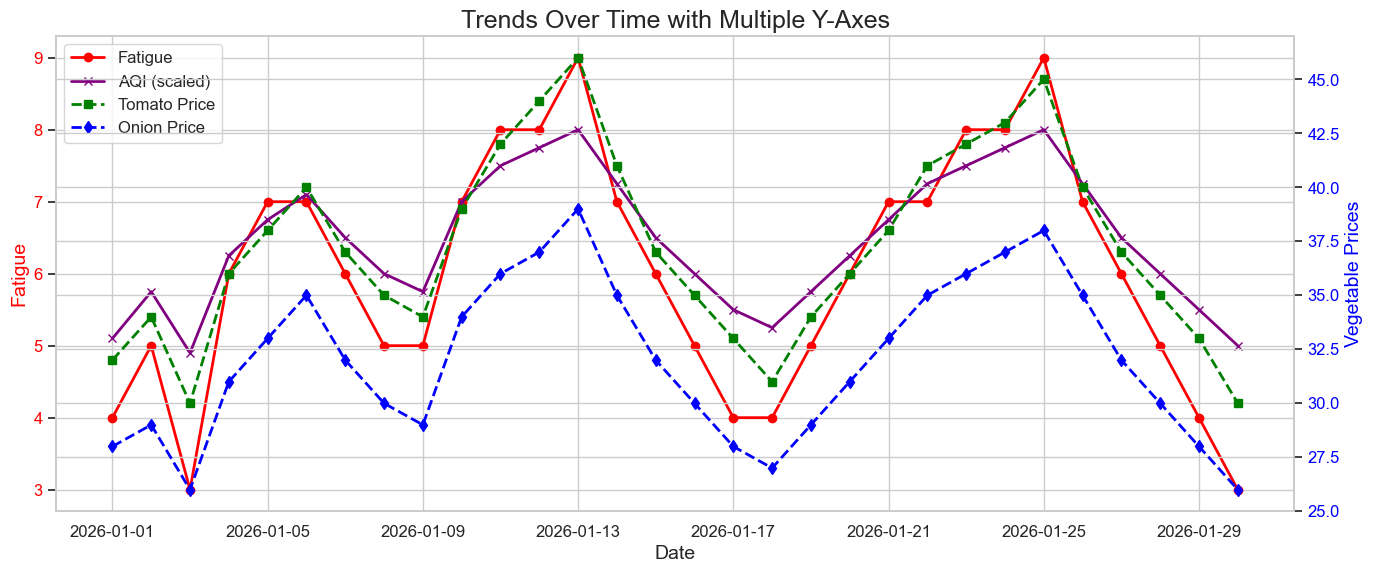

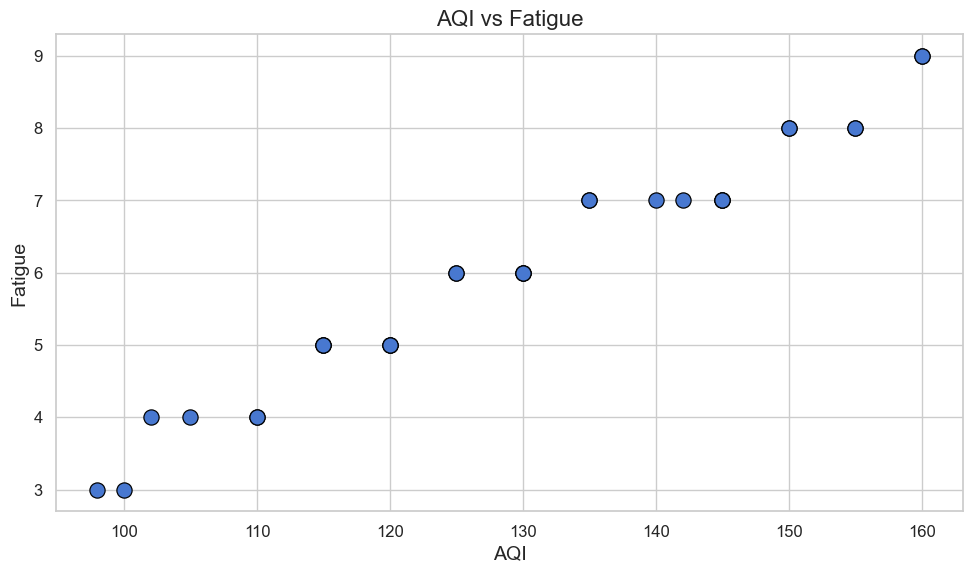

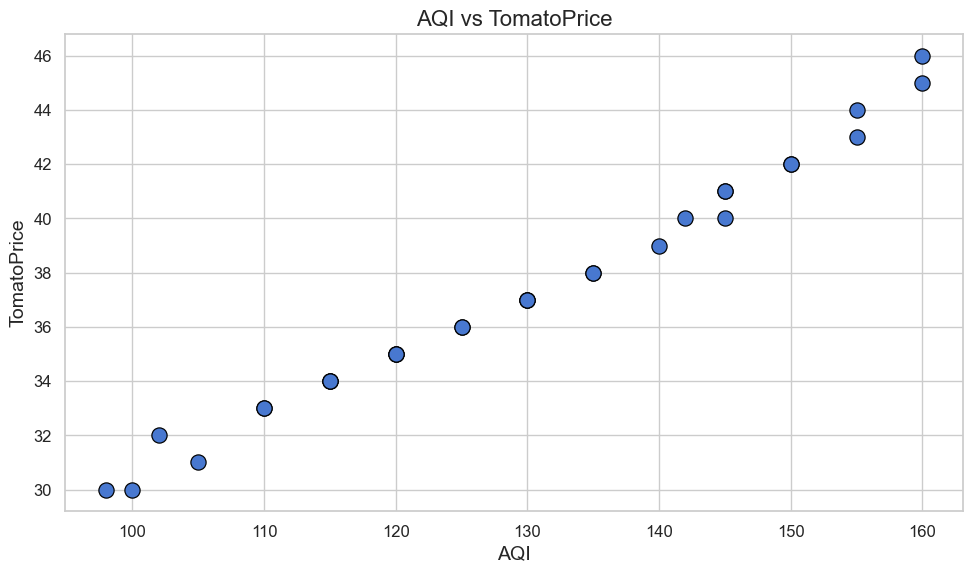

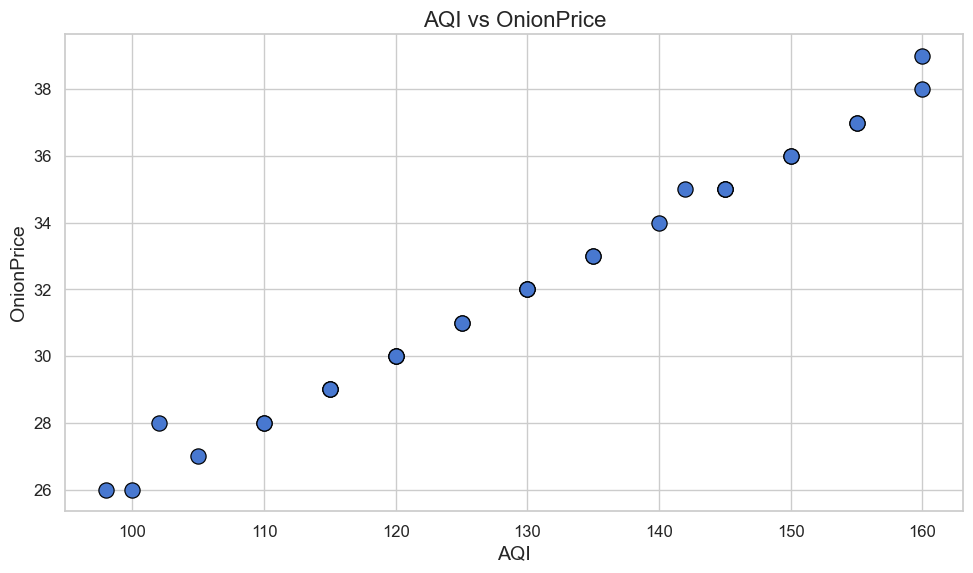

Models trained ✅
Fatigue - MSE: 0.11, R2: 0.94
Tomato Price - MSE: 0.11, R2: 0.99
Onion Price - MSE: 0.03, R2: 1.00


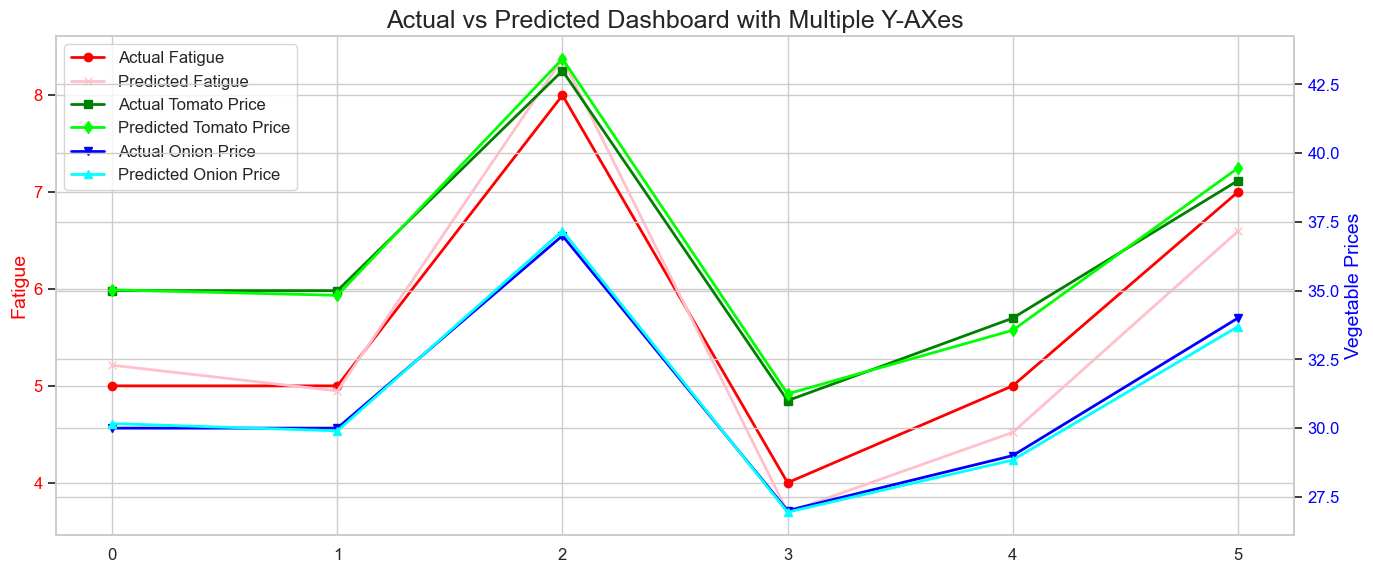


Predicted Fatigue: -1.2
Predicted Tomato Price: 25.37 INR
Predicted Onion Price: 20.75 INR


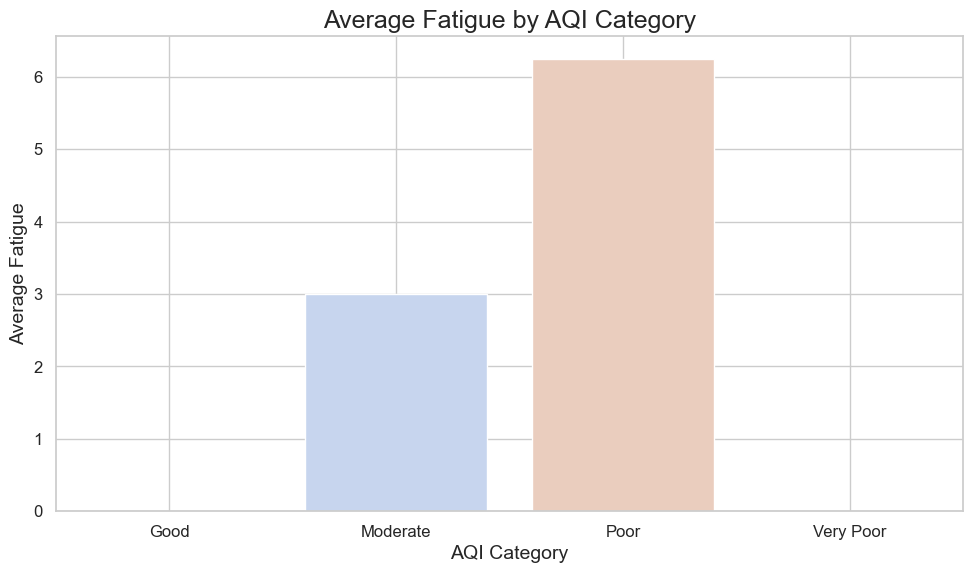

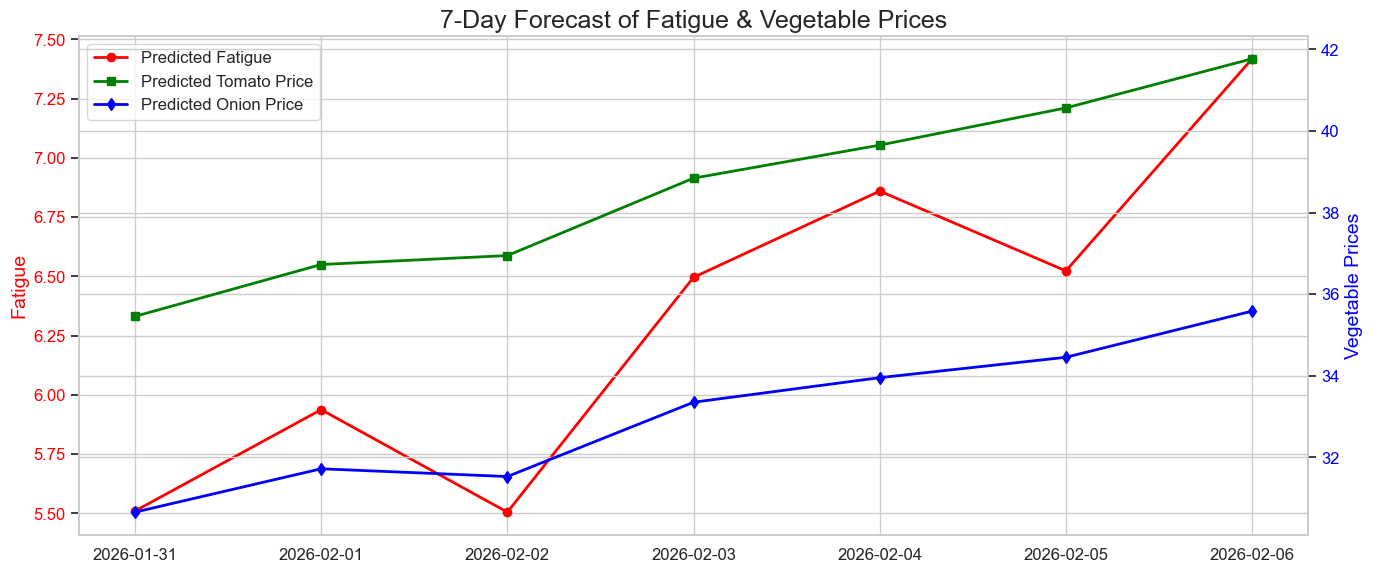

In [ ]:
# %% [1] CHECK AND IMPORT LIBRARIES
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]
for p in packages:
    try:
        __import__(p)
    except ImportError:
        install(p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# %% [1b] SET PLOT STYLE
sns.set(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

print("Libraries ready ✅")

# %% [2] LOAD DATA
try:
    data = pd.read_csv("final_data.csv")
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: final_data.csv not found.")

data['Date'] = pd.to_datetime(data['Date'])
data.head()

# %% [3] BASIC INFO & CHECKS
print("Data Info:")
print(data.info())
print("\nDescriptive Stats:")
print(data.describe())
print("\nMissing values per column:")
print(data.isnull().sum())

# %% [4] CORRELATION HEATMAP
numeric_data = data.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", linewidths=1.5, linecolor='gray')
plt.title("Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()

# %% [5] TREND OVER TIME (MULTIPLE Y-AXES)
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(data['Date'], data['Fatigue'], 'o-', color='red', label='Fatigue', markersize=6)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Fatigue", color='red', fontsize=14)
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(data['Date'], data['TomatoPrice'], 's--', color='green', label='Tomato Price', markersize=6)
ax2.plot(data['Date'], data['OnionPrice'], 'd--', color='blue', label='Onion Price', markersize=6)
ax2.set_ylabel("Vegetable Prices", color='blue', fontsize=14)
ax2.tick_params(axis='y', labelcolor='blue')

ax1.plot(data['Date'], data['AQI']/20, 'x-', color='purple', label='AQI (scaled)', markersize=6)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)

plt.title("Trends Over Time with Multiple Y-Axes", fontsize=18)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# %% [6] SCATTER PLOTS
for col in ['Fatigue','TomatoPrice','OnionPrice']:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x='AQI', y=col, data=data, s=120, edgecolor='black')
    plt.title(f"AQI vs {col}", fontsize=16)
    plt.xlabel("AQI", fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# %% [7] PREPARE DATA FOR ML
X = data[['AQI', 'Humidity', 'Temperature']]
y_fatigue = data['Fatigue']
y_tomato = data['TomatoPrice']
y_onion = data['OnionPrice']

X_train, X_test, y_train_fatigue, y_test_fatigue = train_test_split(X, y_fatigue, test_size=0.2, random_state=42)
_, _, y_train_tomato, y_test_tomato = train_test_split(X, y_tomato, test_size=0.2, random_state=42)
_, _, y_train_onion, y_test_onion = train_test_split(X, y_onion, test_size=0.2, random_state=42)

# %% [8] TRAIN LINEAR REGRESSION
model_fatigue = LinearRegression().fit(X_train, y_train_fatigue)
model_tomato = LinearRegression().fit(X_train, y_train_tomato)
model_onion = LinearRegression().fit(X_train, y_train_onion)
print("Models trained ✅")

# %% [9] PREDICTIONS
y_pred_fatigue = model_fatigue.predict(X_test)
y_pred_tomato = model_tomato.predict(X_test)
y_pred_onion = model_onion.predict(X_test)

# %% [10] EVALUATE MODELS
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} - MSE: {mse:.2f}, R2: {r2:.2f}")

evaluate(y_test_fatigue, y_pred_fatigue, "Fatigue")
evaluate(y_test_tomato, y_pred_tomato, "Tomato Price")
evaluate(y_test_onion, y_pred_onion, "Onion Price")

# %% [11] DASHBOARD PLOT (MULTIPLE Y-AXES)
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(y_test_fatigue.values, 'o-', color='red', label='Actual Fatigue', markersize=6)
ax1.plot(y_pred_fatigue, 'x-', color='pink', label='Predicted Fatigue', markersize=6)
ax1.set_ylabel("Fatigue", color='red', fontsize=14)
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(y_test_tomato.values, 's-', color='green', label='Actual Tomato Price', markersize=6)
ax2.plot(y_pred_tomato, 'd-', color='lime', label='Predicted Tomato Price', markersize=6)
ax2.plot(y_test_onion.values, 'v-', color='blue', label='Actual Onion Price', markersize=6)
ax2.plot(y_pred_onion, '^-', color='cyan', label='Predicted Onion Price', markersize=6)
ax2.set_ylabel("Vegetable Prices", color='blue', fontsize=14)
ax2.tick_params(axis='y', labelcolor='blue')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)

plt.title("Actual vs Predicted Dashboard with Multiple Y-AXes", fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

# %% [12] SAFE INTERACTIVE PREDICTION
def get_int_input(prompt):
    while True:
        try:
            value = int(input(prompt))
            return value
        except ValueError:
            print("Please enter a valid number!")

aqi_input = get_int_input("Enter AQI (98-160): ")
humidity_input = get_int_input("Enter Humidity (65-80): ")
temp_input = get_int_input("Enter Temperature (26-33): ")

new_data = pd.DataFrame({'AQI':[aqi_input],'Humidity':[humidity_input],'Temperature':[temp_input]})
pred_fatigue = model_fatigue.predict(new_data)[0]
pred_tomato = model_tomato.predict(new_data)[0]
pred_onion = model_onion.predict(new_data)[0]

print(f"\nPredicted Fatigue: {pred_fatigue:.1f}")
print(f"Predicted Tomato Price: {pred_tomato:.2f} INR")
print(f"Predicted Onion Price: {pred_onion:.2f} INR")

# %% [13] ADD AQI CATEGORY
def aqi_category(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 200: return "Poor"
    else: return "Very Poor"

data['AQI_Category'] = data['AQI'].apply(aqi_category)

# %% [14] BAR PLOT: AVERAGE FATIGUE PER AQI CATEGORY (NO WARNING)
avg_fatigue = data.groupby('AQI_Category')['Fatigue'].mean().reindex(["Good","Moderate","Poor","Very Poor"])
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_fatigue.index, 
    y=avg_fatigue.values, 
    palette="coolwarm", 
    dodge=False,
    hue=avg_fatigue.index,  # fix warning
    legend=False
)
plt.title("Average Fatigue by AQI Category", fontsize=18)
plt.ylabel("Average Fatigue")
plt.xlabel("AQI Category")
plt.grid(True)
plt.tight_layout()
plt.show()

# %% [15] 7-DAY FORECAST (SAFE)
future_features = pd.DataFrame({
    'AQI': [120,125,130,135,140,145,150],
    'Humidity': [72,73,71,74,75,73,76],
    'Temperature': [29,30,29,31,30,32,31]
})

future_fatigue = model_fatigue.predict(future_features)
future_tomato = model_tomato.predict(future_features)
future_onion = model_onion.predict(future_features)

future_dates = pd.date_range(start=data['Date'].max() + pd.Timedelta(days=1), periods=7)
future_data = future_features.copy()
future_data['Date'] = future_dates
future_data['Predicted_Fatigue'] = future_fatigue
future_data['Predicted_TomatoPrice'] = future_tomato
future_data['Predicted_OnionPrice'] = future_onion

# %% [16] PLOT 7-DAY FORECAST
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(future_data['Date'], future_data['Predicted_Fatigue'], 'o-', color='red', label='Predicted Fatigue', markersize=6)
ax1.set_ylabel("Fatigue", color='red', fontsize=14)
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(future_data['Date'], future_data['Predicted_TomatoPrice'], 's-', color='green', label='Predicted Tomato Price', markersize=6)
ax2.plot(future_data['Date'], future_data['Predicted_OnionPrice'], 'd-', color='blue', label='Predicted Onion Price', markersize=6)
ax2.set_ylabel("Vegetable Prices", color='blue', fontsize=14)
ax2.tick_params(axis='y', labelcolor='blue')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)

plt.title("7-Day Forecast of Fatigue & Vegetable Prices", fontsize=18)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
